Mounted at /content/drive
El siguiente DataSet contiene un conjunto de datos de canciones de Spotify correspondientes a distintas decadas, desde los 60s hasta 10s.
En el presente trabajo se analizaran las caracteristicas musicales que influyen en la popularidad de una cancion, para luego poder predecir si una cancion es popular o no.
En el DataSet hay variables numericas que describen atributos musicales, los cuales son:
-danceability: que tan bailable es la cancion.
-energy: nivel de intensidad de la cancion.
-valence: que tan alegre es la cancion.
Al realizar el EDA buscaremos detectar valores nulos, identificar outliers, evaluar la correlacion entre las variables y analizar que tan relacionadas estan las variables con respecto al nivel de popularidad (target).

Dimensiones: (41106, 20)

Tipos de datos:
track               object
artist              object
uri                 object
danceability        object
energy              object
key                  int64
loudness            o

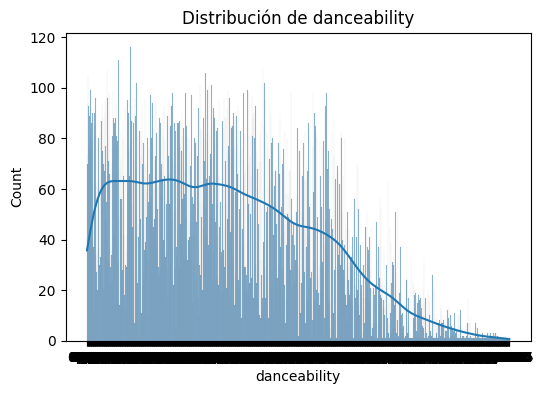

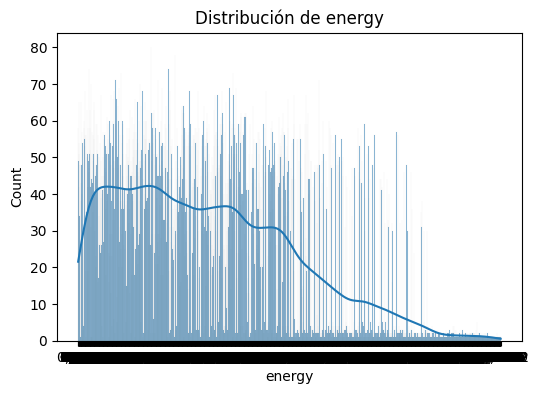

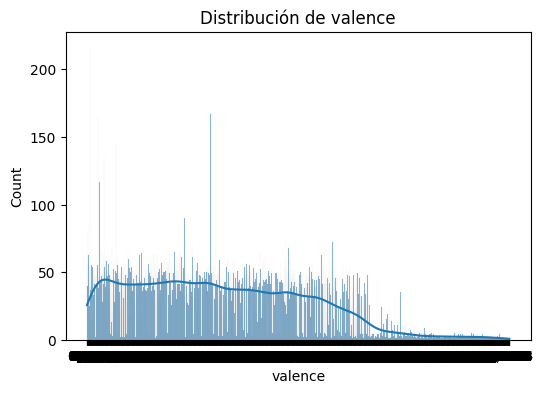

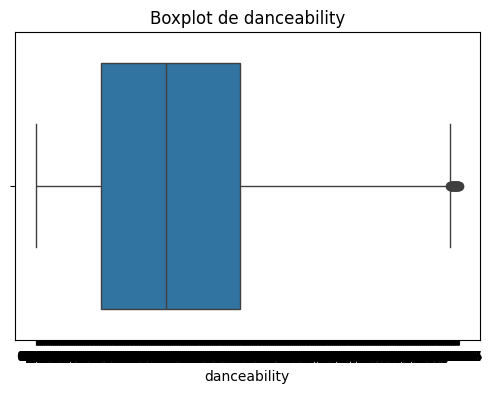

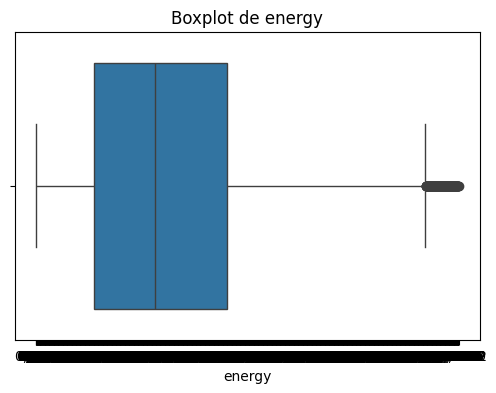

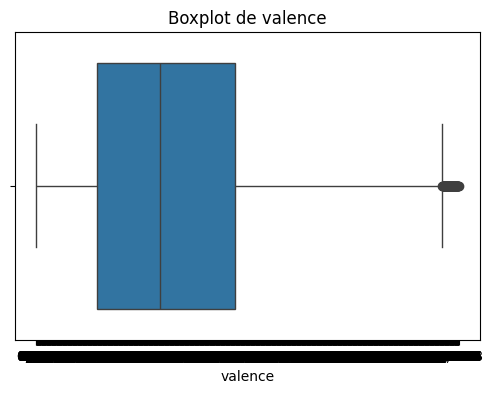

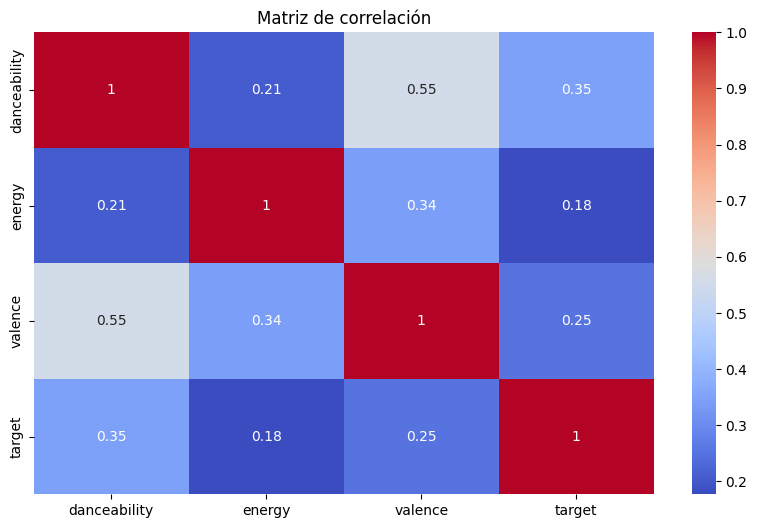

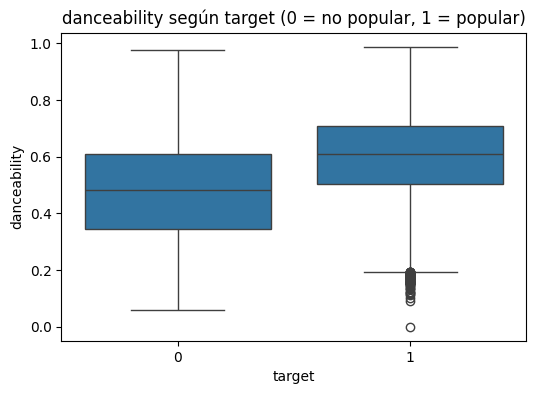

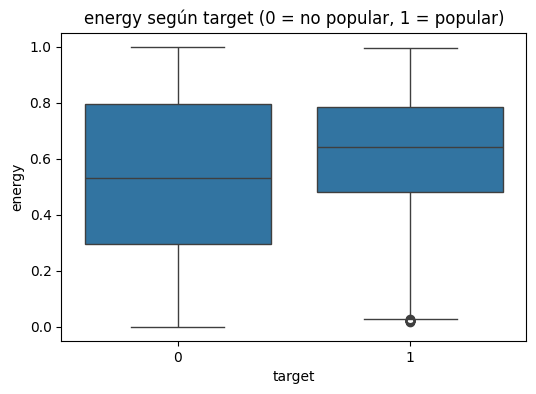

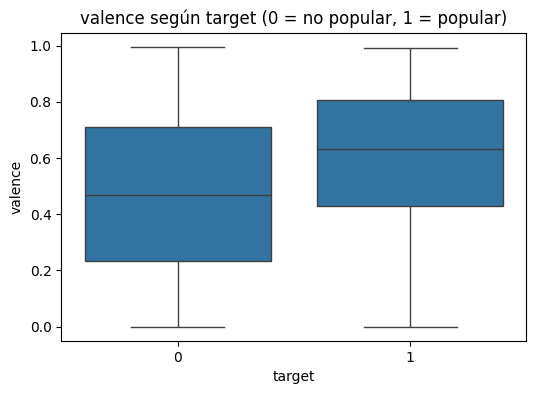


En base a los analisis realizados llegamos a las siguientes conclusiones:
- No se encontraron valores nulos.
- Las distribuciones de danceability, energy y valence presentan sesgos hacia la izquierda, los valores se concentran principalmente entre 0,2 y 0,8, con escasos casos cercanos a 1, lo cual indica que la mayoria de las canciones son moderadamente bailables, energeticas y alegres, pero pocas canciones alcanzan valores extremos.
- Gracias a los Boxplots detectamos la presencia de outliers, especialmente en energy y en menor medida en danceability y valence, lo cual indica que hay canciones con caracteristicas muy distintas al promedio.
- Las correlaciones muestran que la variable mas relacionada con la popularidad es danceability (0.35), seguida de valence (0.25) y en menor medida energy(0.18), esto indica que la bailabilidad y que tan alegre es la cancion tienen mas influencia en su exito que su energia.
- Las canciones populares (target=1) tienden a tener mayores niveles de dan

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

DataSet = "spotify_dataset.csv"
df = pd.read_csv(DataSet)


print("""El siguiente DataSet contiene un conjunto de datos de canciones de Spotify correspondientes a distintas decadas, desde los 60s hasta 10s.
En el presente trabajo se analizaran las caracteristicas musicales que influyen en la popularidad de una cancion, para luego poder predecir si una cancion es popular o no.
En el DataSet hay variables numericas que describen atributos musicales, los cuales son:
-danceability: que tan bailable es la cancion.
-energy: nivel de intensidad de la cancion.
-valence: que tan alegre es la cancion.
Al realizar el EDA buscaremos detectar valores nulos, identificar outliers, evaluar la correlacion entre las variables y analizar que tan relacionadas estan las variables con respecto al nivel de popularidad (target).
""")

print("Dimensiones:", df.shape)
print("\nTipos de datos:")
print(df.dtypes)
print("\nPrimeras filas:")
print(df.head())
print("\nResumen estadístico:")
print(df.describe())


print("\nValores nulos por columna:")
print(df.isnull().sum())


for col in ["danceability", "energy", "valence"]:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f"Distribución de {col}")
    plt.show()


for col in ["danceability", "energy", "valence"]:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot de {col}")
    plt.show()



for col in ["danceability", "energy", "valence", "target"]:
    df[col] = pd.to_numeric(df[col].astype(str).str.replace(",", "."), errors="coerce")

plt.figure(figsize=(10,6))
sns.heatmap(df[["danceability", "energy", "valence", "target"]].corr(),
            cmap="coolwarm", annot=True)
plt.title("Matriz de correlación")
plt.show()



for col in ["danceability", "energy", "valence"]:
    plt.figure(figsize=(6,4))
    sns.boxplot(x="target", y=col, data=df)
    plt.title(f"{col} según target (0 = no popular, 1 = popular)")
    plt.show()


print("""
En base a los analisis realizados llegamos a las siguientes conclusiones:
- No se encontraron valores nulos.
- Las distribuciones de danceability, energy y valence presentan sesgos hacia la izquierda, los valores se concentran principalmente entre 0,2 y 0,8, con escasos casos cercanos a 1, lo cual indica que la mayoria de las canciones son moderadamente bailables, energeticas y alegres, pero pocas canciones alcanzan valores extremos.
- Gracias a los Boxplots detectamos la presencia de outliers, especialmente en energy y en menor medida en danceability y valence, lo cual indica que hay canciones con caracteristicas muy distintas al promedio.
- Las correlaciones muestran que la variable mas relacionada con la popularidad es danceability (0.35), seguida de valence (0.25) y en menor medida energy(0.18), esto indica que la bailabilidad y que tan alegre es la cancion tienen mas influencia en su exito que su energia.
- Las canciones populares (target=1) tienden a tener mayores niveles de danceability y valence. En cambio, la diferencia en energy entre canciones populares y no populares es menos marcada, lo cual indica que la intensidad por si sola no determina la popularidad.
""")
